In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

In [ ]:
"""Given a zip file of .txt files containing emails, create a machine learning model that can predict whether a given sentence is spam or ham. Spam
is characterized as unimportant, at times malicious messages from unknown senders while ham is truthful messages from recognized senders. The machine
learning model must be written in Python."""

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [39]:
"""I downloaded the zip file from Mr. Rivero's google drive and unpacked the zip file by using the terminal. I set all of the text files under the
directory 'data'."""

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

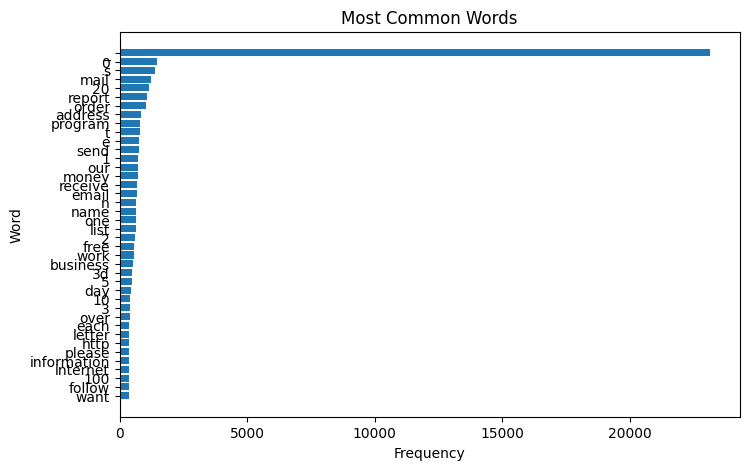

In [28]:
import csv
import re
import pandas as pd
import matplotlib.pyplot as plt

all_text=""
with open('emails.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        all_text += row['message'] + " "
# Convert to series of tokens
words = re.findall(r'\b\w+\b', all_text.lower())
word_series = pd.Series(words)

# Disregard common nonessential words
stop_words = set([
    'the', 'a', 'an', 'is', 'it', 'and', 'to', 'of', 'in', 'for', 'with', 
    'on', 'that', 'we', 'you', 'i', 'was', 'are', 'not', 'as', 'this', 'be', 
    'but', 'by', 'at', 'have', 'from', 'so', 'if', 'me', 'my', 'or', 
])


filtered_words = word_series[~word_series.isin(stop_words)]
top_n = 40
word_counts = filtered_words.value_counts().head(top_n)

df_counts = word_counts.reset_index()
df_counts.columns = ['Word', 'Frequency']

plt.figure(figsize=(8, 5)) 
df_plot = df_counts.iloc[::-1]
plt.barh(df_plot['Word'], df_plot['Frequency'])

plt.title('Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

"""
    Insights:
        Some insights I have gathered are that most of the emails start with a subject line on the first line; then, the rest of the email is
        a message until it gets to about the last line, where we can typically find an @ representing an email address. I have also noticed that the emails
        are very unclean, littered with punctuation issues. Though this may not effect the message itself, it coudl effect the extraction of the 
        sender value. Moreover, as displayed by the graph, there are some words that particularly stick out to me as spam, such as "money", "free",
        and "http". The most common word was '0', along with several other single letter words.
    Bias:
        My bias is I have a different personal metric of detecting spam than others. For example, my criteria for spam is if it is from an unreliable address,
        makes promises of being free/pleading for money, uses loaded language, or includes a link. However, some of these can be seen in ham emails,
        and as such my own bias could effect the machine learning model's evaluation of whether an email could be spam or ham.
"""

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [42]:
import csv
import os
import glob
import pandas as pd

directory = 'data/email_archive'
output_filename = 'emails.csv'         
fieldnames = ['Name', 'Subject', 'Sender', 'Message']

with open(output_filename, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()

    for filepath in glob.glob(os.path.join(directory, '*.txt')):
        with open(filepath, 'r') as f:
            content = f.read()
        
        filename = os.path.basename(filepath)
        lines = [line.strip() for line in content.split('\n') if line.strip()]
        data = {'Name': 'Unknown', 'Subject': 'N/A', 'Sender': 'N/A', 'Message': ''}

        start_idx = 0 # Where the message should start
        for line in lines:
            if "Subject:" in line:
                start_idx = lines.index(line)+1
                subject = line.split("Subject:")[1].strip().lower() # Get everything after subject
                data['Subject'] = re.sub(r'[^a-z0-9\s]', '', subject)
                break
                
        # Find line the sender is in
        sender_line = ""
        for line in lines[-5:]:
            if '@' in line:
                sender_line = line
                break
        end_idx = len(lines) # Know when the message should stop
        if sender_line:
                end_idx=lines.index(sender_line)
                temp_line = sender_line.replace(' @ ', '@').replace('[source:', '').strip() # Get rid of spaces and source tag
                at_index = temp_line.find('@')

                # Look backwards until you get to a space, front of sender address
                if at_index != -1:
                    start_id = 0
                    for i in range(at_index - 1, -1, -1):
                        if temp_line[i].isspace():
                            start_id = i + 1
                            break
                    
                    # Look forward until you get to a space, back of sender address
                    end_address = len(temp_line)
                    for i in range(at_index + 1, len(temp_line)):
                        if temp_line[i].isspace():
                            end_address = i
                            break
                            
                    sender = temp_line[start_id:end_address].strip('.,-').lower() # Clean punctuation
                    data['Sender']=re.sub(r'\b\d\b', '', sender)

        data['Name'] = filename.lower()
                
        # Extract everything between subject and sender, that will be the message
        message_lines = lines[start_idx:end_idx]     
        full_message = ' '.join(message_lines)
        full_message = re.sub(r'[^a-z0-9\s]', '', full_message)
        full_message = [word for word in full_message if word not in stop_words]
        data['Message'] = ''.join(full_message).strip()
        writer.writerow(data)

df = pd.read_csv('emails.csv')

""" I converted each of the .txt files from the email archive to a row in a csv file, with headers 'Name', 'Subject', 'Sender', and 'Message' 
before converting the csv file to a pandas dataframe for the machine learning model. I did this by iterating through each text file, splitting each text file into lines,
searching for the subject line usig indeces, and finding the message by initializing it to everything between the subject line and sender line."""

" I converted each of the .txt files from the email archive to a row in a csv file, with headers 'Name', 'Subject', 'Sender', and 'Message' \nbefore converting the csv file to a pandas dataframe for the machine learning model. I did this by iterating through each text file, splitting each text file into lines,\nsearching for the subject line usig indeces, and finding the message by initializing it to everything between the subject line and sender line."

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


Index(['User ID', 'Gender', 'Age', 'EstimatedSalary'], dtype='object')
(800, 4) (201, 4)
Train: 1.0
Test: 0.5223880597014925

            Feature  Importance
3  EstimatedSalary    0.363711
0          User ID    0.355735
2              Age    0.241981
1           Gender    0.038573


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


'\n    Problem: Given a dataset from a company with multiple features, predict the target audience for sales.\n\n    Summary of findings:\n        One of the key findings of the project was that the average salary of the customer was the most\n        important feature, with a 36% importance. The second most important was the User ID, which shows\n        the sequential order of each purchase. This had an importance of 35%. The third most important\n        feature was the Age, with a 26% importance. Overall, the target audience is affluent, middle aged\n        persons who are more likely to purchase later models.\n\n    Detail approach:\n        Using sci-kit learn and Python, I created a Random Forest classifier model using the dataset provided\n        by the company. I was able to predict whether a customer would purchase with 52% accuracy. I saved this\n        trained model.\n\n\n'

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


ValueError: could not convert string to float: 'Female'